# 11 — Immune Cells: Ontology Tree + OOD Design Framework

After the CD4/CD8/thymocyte/T-cell hierarchy work in groups A–D of `01.3`, we are switching the focal task to a **broader immune-cell holdout** problem. This notebook does the design work that does **not** depend on cloud data:

1. Defines the 11 shared immune cell types and their Cell Ontology (CL) IDs.
2. Builds an explicit lineage tree (HSPC → lymphoid / myeloid → effectors / progenitors → terminal types) so the relationships are visible, not implicit.
3. Derives sibling and lineage groupings useful for OOD holdout design.
4. Proposes A/B/C/D-style holdout group templates that **mirror the CD4/CD8/thymocyte/T-cell scheme** (single subtype, near-sibling, lineage, distant control).
5. Leaves clearly labelled placeholders for the data-dependent steps (per-`(cell_type, tissue, species)` cell counts, focal-type selection, final group sizes).

## Why this design pattern

The CD8 work exploited the fact that the holdout had **near siblings** (CD4, thymocyte) and a **lineage parent** (T cell) in the training data. That gave us a controlled axis: how does prediction quality depend on phylogenetic distance from the seen population?

We want the same axis for immune cells, but the structure is richer (myeloid vs lymphoid, granulocyte vs mononuclear, B-derived plasma cells, etc). This notebook makes that structure explicit so the choice of focal cell type and holdout group is auditable.

## What this notebook does NOT do

- It does **not** count cells, choose a focal type, or build the actual `.h5ad` files for training. Those steps belong in `11.1` (data-dependent), to be filled in once cloud access is restored.
- It does **not** rebuild ortholog alignment or HVG. Those come from the `01.x` pipeline, which 11.1 will reuse.
- It does **not** include drug-style perturbation conditions; the immune switch keeps the species-cross structure of the existing experiments.

## 0. Imports

Pure-Python visualization of the ontology tree. `networkx` is the only non-standard dependency. If it is not in the env, install with `pip install networkx`.

In [1]:
import json
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

try:
    import networkx as nx
    HAS_NX = True
except ImportError:
    HAS_NX = False
    print("networkx not installed; install with `pip install networkx` to enable graph drawing.")

OUT_DIR = Path(".") / "immune_ontology_outputs"
OUT_DIR.mkdir(exist_ok=True)
print(f"Output dir: {OUT_DIR.resolve()}")

Output dir: /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/speciesOT/baseline/analysis/immune_ontology_outputs


## 1. The 11 shared immune cell types

These are the types provided by the user as already-shared between Tabula Sapiens and Tabula Muris. We attach Cell Ontology (CL) identifiers (consistent with `cell_type_ontology_term_id` in the source AnnDatas) and a short biological note for each.

Note the user's spelling "HPSC" is used in the project; the canonical term is **HSPC** (hematopoietic stem and progenitor cell). We use HSPC consistently here and add HPSC as an alias to avoid confusion downstream.

In [2]:
IMMUNE_TYPES = [
    {"label": "HSPC",            "alias": "HPSC", "cl_id": "CL:0008001",
     "lineage": "progenitor",   "role": "Stem/progenitor of all blood cells"},
    {"label": "T cell",          "alias": None,   "cl_id": "CL:0000084",
     "lineage": "lymphoid",     "role": "Adaptive immunity, includes CD4/CD8/regulatory"},
    {"label": "B cell",          "alias": None,   "cl_id": "CL:0000236",
     "lineage": "lymphoid",     "role": "Adaptive humoral immunity, parent of plasma cell"},
    {"label": "plasma cell",     "alias": None,   "cl_id": "CL:0000786",
     "lineage": "lymphoid",     "role": "Antibody-secreting differentiated B cell"},
    {"label": "NK cell",         "alias": None,   "cl_id": "CL:0000623",
     "lineage": "lymphoid",     "role": "Innate cytotoxic lymphocyte"},
    {"label": "monocyte",        "alias": None,   "cl_id": "CL:0000576",
     "lineage": "myeloid",      "role": "Mononuclear phagocyte precursor in blood"},
    {"label": "macrophage",      "alias": None,   "cl_id": "CL:0000235",
     "lineage": "myeloid",      "role": "Tissue-resident phagocyte (often monocyte-derived)"},
    {"label": "dendritic cell",  "alias": None,   "cl_id": "CL:0000451",
     "lineage": "myeloid",      "role": "Antigen-presenting cell (mixed origin)"},
    {"label": "neutrophil",      "alias": None,   "cl_id": "CL:0000775",
     "lineage": "myeloid",      "role": "Granulocyte; first responder to infection"},
    {"label": "basophil",        "alias": None,   "cl_id": "CL:0000767",
     "lineage": "myeloid",      "role": "Granulocyte; allergic/parasitic responses"},
    {"label": "erythrocyte",     "alias": None,   "cl_id": "CL:0000232",
     "lineage": "myeloid",      "role": "Red blood cell; oxygen transport"},
]

immune_df = pd.DataFrame(IMMUNE_TYPES).set_index("label")
print(immune_df.to_string())

               alias       cl_id     lineage                                                role
label                                                                                           
HSPC            HPSC  CL:0008001  progenitor                  Stem/progenitor of all blood cells
T cell          None  CL:0000084    lymphoid      Adaptive immunity, includes CD4/CD8/regulatory
B cell          None  CL:0000236    lymphoid    Adaptive humoral immunity, parent of plasma cell
plasma cell     None  CL:0000786    lymphoid            Antibody-secreting differentiated B cell
NK cell         None  CL:0000623    lymphoid                         Innate cytotoxic lymphocyte
monocyte        None  CL:0000576     myeloid            Mononuclear phagocyte precursor in blood
macrophage      None  CL:0000235     myeloid  Tissue-resident phagocyte (often monocyte-derived)
dendritic cell  None  CL:0000451     myeloid              Antigen-presenting cell (mixed origin)
neutrophil      None  CL:00007

## 2. Lineage tree

The 11 target types do not form a flat partition. We model them as a 4-level rooted DAG using the simplified hematopoietic lineage:

```
Level 0: HSPC
Level 1: Common lymphoid progenitor   |   Common myeloid progenitor
Level 2: T cell, B cell, NK cell      |   monocyte, granulocyte progenitor, erythrocyte
Level 3: plasma cell (B-derived)       |   macrophage, dendritic cell (monocyte-related)
                                      |   neutrophil, basophil (granulocyte-derived)
```

We include two **non-target intermediate nodes** (Common lymphoid progenitor, Common myeloid progenitor, granulocyte progenitor) purely to make the structure explicit. They are visualized in grey; the 11 target types are visualized in blue.

The actual Cell Ontology has a much denser DAG (a cell type may have multiple `is_a` parents and `develops_from` edges). Our simplification is biased toward the relationships that matter for **OOD distance**: which cells are near siblings, which are lineage cousins, which are cross-lineage.

In [3]:
INTERMEDIATES = {
    "Common lymphoid progenitor": "CL:0000051",
    "Common myeloid progenitor":  "CL:0000049",
    "granulocyte progenitor":     "CL:0000094",
}

EDGES = [
    ("HSPC", "Common lymphoid progenitor"),
    ("HSPC", "Common myeloid progenitor"),
    ("Common lymphoid progenitor", "T cell"),
    ("Common lymphoid progenitor", "B cell"),
    ("Common lymphoid progenitor", "NK cell"),
    ("B cell", "plasma cell"),
    ("Common myeloid progenitor", "monocyte"),
    ("Common myeloid progenitor", "granulocyte progenitor"),
    ("Common myeloid progenitor", "erythrocyte"),
    ("monocyte", "macrophage"),
    ("monocyte", "dendritic cell"),
    ("granulocyte progenitor", "neutrophil"),
    ("granulocyte progenitor", "basophil"),
]

TARGETS = set(immune_df.index)
INTERMED_LABELS = set(INTERMEDIATES.keys())

if HAS_NX:
    G = nx.DiGraph()
    G.add_edges_from(EDGES)
    print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    print(f"  target leaves     : {sorted(n for n in G.nodes() if n in TARGETS and G.out_degree(n) == 0)}")
    print(f"  internal targets  : {sorted(n for n in G.nodes() if n in TARGETS and G.out_degree(n) > 0)}")
    print(f"  intermediates     : {sorted(n for n in G.nodes() if n in INTERMED_LABELS)}")
else:
    G = None

Graph: 14 nodes, 13 edges
  target leaves     : ['NK cell', 'T cell', 'basophil', 'dendritic cell', 'erythrocyte', 'macrophage', 'neutrophil', 'plasma cell']
  internal targets  : ['B cell', 'HSPC', 'monocyte']
  intermediates     : ['Common lymphoid progenitor', 'Common myeloid progenitor', 'granulocyte progenitor']


## 3. Visualize the tree

Manual hierarchical layout, no graphviz dependency. Targets (the 11 user-listed types) are blue circles, intermediates are grey diamonds. Edge directions point from progenitor to descendant.

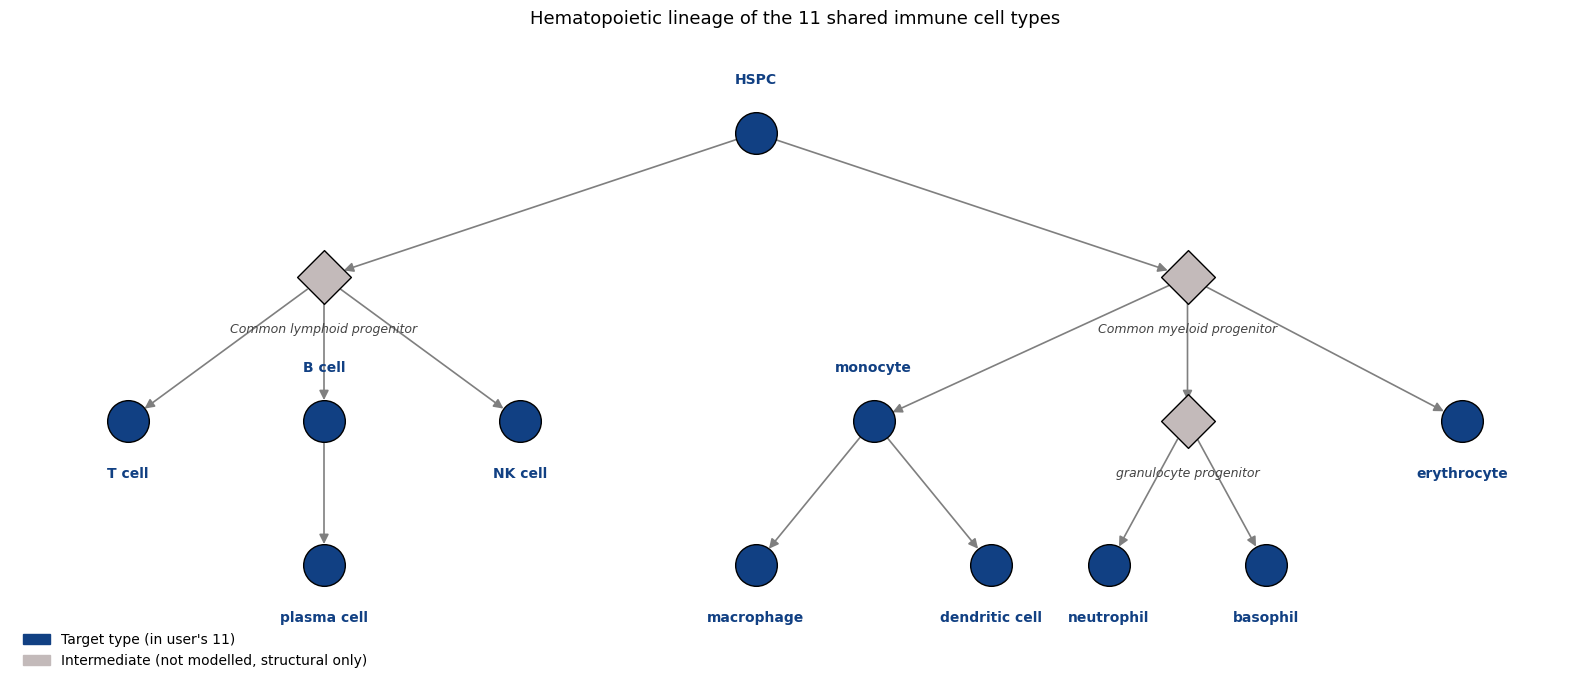

  saved: immune_ontology_outputs/immune_lineage_tree.pdf


In [4]:
POS = {
    "HSPC":                       ( 0.0, 4.0),
    "Common lymphoid progenitor": (-5.5, 3.0),
    "Common myeloid progenitor":  ( 5.5, 3.0),
    "T cell":                     (-8.0, 2.0),
    "B cell":                     (-5.5, 2.0),
    "NK cell":                    (-3.0, 2.0),
    "monocyte":                   ( 1.5, 2.0),
    "granulocyte progenitor":     ( 5.5, 2.0),
    "erythrocyte":                ( 9.0, 2.0),
    "plasma cell":                (-5.5, 1.0),
    "macrophage":                 ( 0.0, 1.0),
    "dendritic cell":             ( 3.0, 1.0),
    "neutrophil":                 ( 4.5, 1.0),
    "basophil":                   ( 6.5, 1.0),
}

LABEL_OFFSET = 0.32

def draw_tree(G, pos, ax, title=""):
    if G is None:
        ax.text(0.5, 0.5, "Install networkx to render this graph.", ha="center", va="center")
        ax.axis("off")
        return
    target_nodes = [n for n in G.nodes() if n in TARGETS]
    interm_nodes = [n for n in G.nodes() if n in INTERMED_LABELS]

    nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowsize=14,
                           edge_color="#7f7f7f", width=1.2, node_size=900)
    nx.draw_networkx_nodes(G, pos, nodelist=target_nodes, ax=ax,
                           node_color="#114083", node_size=900, node_shape="o",
                           edgecolors="black", linewidths=1.0)
    nx.draw_networkx_nodes(G, pos, nodelist=interm_nodes, ax=ax,
                           node_color="#C3BABA", node_size=750, node_shape="D",
                           edgecolors="black", linewidths=1.0)

    for n in target_nodes:
        x, y = pos[n]
        is_leaf = (G.out_degree(n) == 0)
        # Leaves: label below; internal: label above
        offset = -LABEL_OFFSET if is_leaf else LABEL_OFFSET
        va = "top" if is_leaf else "bottom"
        ax.text(x, y + offset, n, ha="center", va=va, fontsize=10, fontweight="bold", color="#114083")
    for n in interm_nodes:
        x, y = pos[n]
        ax.text(x, y - LABEL_OFFSET, n, ha="center", va="top", fontsize=9,
                fontstyle="italic", color="#444444")

    ax.set_title(title, fontsize=13)
    ax.set_xlim(-9.5, 10.5); ax.set_ylim(0.2, 4.7)
    ax.axis("off")

fig, ax = plt.subplots(figsize=(16, 7))
draw_tree(G, POS, ax, title="Hematopoietic lineage of the 11 shared immune cell types")
legend_handles = [
    mpatches.Patch(color="#114083", label="Target type (in user's 11)"),
    mpatches.Patch(color="#C3BABA", label="Intermediate (not modelled, structural only)"),
]
ax.legend(handles=legend_handles, loc="lower left", frameon=False)
plt.tight_layout()
plt.savefig(OUT_DIR / "immune_lineage_tree.pdf", bbox_inches="tight")
plt.savefig(OUT_DIR / "immune_lineage_tree.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"  saved: {OUT_DIR/'immune_lineage_tree.pdf'}")

## 4. Lineage and sibling analysis

Three useful operations for OOD design:

- **Lineage(t)**: which broad lineage (lymphoid / myeloid / progenitor) the type belongs to.
- **Siblings(t)**: which other target types share a parent with `t` in the simplified tree.
- **Cousins(t)**: types that share a grandparent but not a parent (e.g., neutrophil and macrophage are myeloid cousins).

These power the A/B/C/D group templates in section 5.

In [5]:
def parent_of(G, n):
    preds = list(G.predecessors(n))
    return preds[0] if preds else None

def ancestors_chain(G, n):
    chain = []
    cur = n
    while True:
        p = parent_of(G, cur)
        if p is None: break
        chain.append(p); cur = p
    return chain

def siblings(G, n):
    p = parent_of(G, n)
    if p is None: return []
    return [s for s in G.successors(p) if s != n and s in TARGETS]

def cousins(G, n):
    p = parent_of(G, n)
    if p is None: return []
    gp = parent_of(G, p)
    if gp is None: return []
    cous = []
    for sib_of_p in G.successors(gp):
        if sib_of_p == p: continue
        for c in G.successors(sib_of_p):
            if c in TARGETS and c != n:
                cous.append(c)
        if sib_of_p in TARGETS and sib_of_p != n:
            cous.append(sib_of_p)
    return cous

if HAS_NX:
    rel_rows = []
    for t in immune_df.index:
        rel_rows.append({
            "type":      t,
            "lineage":   immune_df.loc[t, "lineage"],
            "parent":    parent_of(G, t),
            "siblings":  ", ".join(siblings(G, t)),
            "cousins":   ", ".join(cousins(G, t)),
            "ancestors": " -> ".join(ancestors_chain(G, t)),
        })
    rel_df = pd.DataFrame(rel_rows).set_index("type")
    with pd.option_context("display.max_colwidth", 80, "display.width", 200):
        print(rel_df.to_string())
    rel_df.to_csv(OUT_DIR / "immune_lineage_relations.csv")

                   lineage                      parent         siblings                                            cousins                                                    ancestors
type                                                                                                                                                                                   
HSPC            progenitor                        None                                                                                                                                 
T cell            lymphoid  Common lymphoid progenitor  B cell, NK cell                              monocyte, erythrocyte                           Common lymphoid progenitor -> HSPC
B cell            lymphoid  Common lymphoid progenitor  T cell, NK cell                              monocyte, erythrocyte                           Common lymphoid progenitor -> HSPC
plasma cell       lymphoid                      B cell                          

## 5. OOD group templates (mirror of CD4/CD8 A–D)

Each focal type gets a **four-group template** parallel to `01.3`:

| Group | Holdout content | Purpose |
|-------|-----------------|---------|
| **A** | Focal type only | Single-subtype OOD baseline |
| **B** | Focal + nearest sibling | Near OOD (closely related siblings excluded too) |
| **C** | Focal + all siblings (lineage subtree) | Lineage OOD (whole local branch held out) |
| **D** | One distant cross-lineage type | Distant OOD control (different lineage entirely) |

We generate templates for several plausible focal types so the mentor meeting can pick one based on biology and (later) data availability. We do **not** commit to a focal here.

In [6]:
def cl_id(t):
    return immune_df.loc[t, "cl_id"] if t in immune_df.index else INTERMEDIATES.get(t, "")

def make_template(focal, distant):
    """Build A/B/C/D for a focal target type, given a chosen distant control."""
    sibs = siblings(G, focal) if HAS_NX else []
    return {
        "focal": focal,
        "distant": distant,
        "groups": {
            "A": {"name": f"{focal}".replace(" ", "_"),
                  "holdout": [focal],
                  "holdout_ids": [cl_id(focal)],
                  "description": f"{focal} held out alone"},
            "B": {"name": f"{focal}_+nearsib".replace(" ", "_"),
                  "holdout": [focal] + (sibs[:1] if sibs else []),
                  "holdout_ids": [cl_id(focal)] + ([cl_id(sibs[0])] if sibs else []),
                  "description": f"{focal} + nearest sibling held out"},
            "C": {"name": f"{focal}_lineage".replace(" ", "_"),
                  "holdout": [focal] + sibs,
                  "holdout_ids": [cl_id(focal)] + [cl_id(s) for s in sibs],
                  "description": f"{focal} + all siblings (lineage subtree)"},
            "D": {"name": f"distant_{distant}".replace(" ", "_"),
                  "holdout": [distant],
                  "holdout_ids": [cl_id(distant)],
                  "description": f"{distant} held out alone (cross-lineage control)"},
        },
    }

CANDIDATES = [
    ("dendritic cell", "NK cell"),
    ("NK cell",        "macrophage"),
    ("macrophage",     "T cell"),
    ("plasma cell",    "neutrophil"),
    ("neutrophil",     "B cell"),
]

templates = {focal: make_template(focal, distant) for focal, distant in CANDIDATES}

for focal, tpl in templates.items():
    print(f"=== focal: {focal}   distant control: {tpl['distant']}")
    for g, info in tpl["groups"].items():
        print(f"  {g}  {info['name']:30s}  holdout = {info['holdout']}")
    print()

with open(OUT_DIR / "immune_ood_templates.json", "w") as fp:
    json.dump(templates, fp, indent=2)
print(f"  saved: {OUT_DIR/'immune_ood_templates.json'}")

=== focal: dendritic cell   distant control: NK cell
  A  dendritic_cell                  holdout = ['dendritic cell']
  B  dendritic_cell_+nearsib         holdout = ['dendritic cell', 'macrophage']
  C  dendritic_cell_lineage          holdout = ['dendritic cell', 'macrophage']
  D  distant_NK_cell                 holdout = ['NK cell']

=== focal: NK cell   distant control: macrophage
  A  NK_cell                         holdout = ['NK cell']
  B  NK_cell_+nearsib                holdout = ['NK cell', 'T cell']
  C  NK_cell_lineage                 holdout = ['NK cell', 'T cell', 'B cell']
  D  distant_macrophage              holdout = ['macrophage']

=== focal: macrophage   distant control: T cell
  A  macrophage                      holdout = ['macrophage']
  B  macrophage_+nearsib             holdout = ['macrophage', 'dendritic cell']
  C  macrophage_lineage              holdout = ['macrophage', 'dendritic cell']
  D  distant_T_cell                  holdout = ['T cell']

=== focal: pl

## 6. Focal-type decision criteria

When the cloud is back and we can count cells, the focal type for the first round of immune-switch experiments should be chosen by these criteria, in order:

1. **Sufficient matched cells per `(species, tissue)` after ortholog alignment.** The CD8 baseline has ~N matched cells per group; pick a focal type that gives at least the same order of magnitude so we are comparing apples to apples.
2. **Has at least one near sibling in the tree** (so Group B is meaningful) **and** at least 2 siblings (so Group C is meaningful).
3. **Has a distant cross-lineage type with enough cells** (so Group D is meaningful as a control).
4. **Tissue diversity**: present in ≥2 tissues in both species, otherwise the model can memorize tissue.
5. **Biological interest**: dendritic cells and macrophages are particularly compelling because they are tissue-resident and have known cross-species conservation differences.

## 7. Data-dependent placeholders (to be filled in by `11.1`)

The cells below are scaffolds. Their bodies are deferred until cloud access is restored. Do **not** treat the values inside as real.

In [7]:
# DATA-DEPENDENT — scaffold only. Run on cloud.
#
# Once cloud access is back:
#   1. Load mouse_full + human_full from the same paths as 01.3
#   2. Promote .raw -> .X, ortholog align, match by (cell_type, tissue)
#   3. For each focal candidate in CANDIDATES above:
#         filter matched cells to the focal lineage subtree + its distant control
#         report n_cells per (species, tissue, cell_type)
#   4. Score each candidate against the criteria in section 6
#   5. Save the chosen focal + final A/B/C/D group definitions to
#         immune_ontology_outputs/immune_ood_chosen.json
#
# def count_matched_immune_cells(matched_mouse, matched_human, types):
#     ...
#     return counts_df  # rows: (species, tissue, cell_type), col: n
#
# def score_focal_candidates(counts_df, candidates, min_matched=500):
#     ...
#     return ranking_df

print("Scaffolded. Fill in 11.1 once cloud data is accessible.")

Scaffolded. Fill in 11.1 once cloud data is accessible.


## Next steps

1. **`11.1_immune_cell_data_audit.ipynb`** (data-dependent): compute matched cell counts per `(species, tissue, cell_type)` for the 11 immune types; rank candidates from section 5; commit a single focal type and final A/B/C/D group definitions to `immune_ontology_outputs/immune_ood_chosen.json`.
2. **Update `01.3` (or fork to `01.5`)** to take a `GROUPS` definition that includes both T-cell groups and the immune-switch groups, so a single data-prep run produces both families of holdout files.
3. **`12_figure_g_replication.ipynb`** (independent track): replicate the CellOT paper Fig. 3g marginal-density plot using the existing `cd8` evals (`cellot/evals_ood_data_space/imputed.h5ad` + `impact_or/evals_ood_data_space/imputed.h5ad` + the held-out treated and the source control). Code is `CellOT/cellot/cellot/utils/viz.py:plot_marginals` — `seaborn.kdeplot(common_norm=False)` per gene, with the published red/blue/grey palette.
4. **CD4 → CD8 setup (`02.x`)**: write the data-prep + train scripts for the Normal-CellOT-with-species-OOD design discussed in chat. Two arms: pure cross-species (mouse-only training) and mixed-species (human CD4 included as source).
5. After meeting: pick the winning HVG flavor from `01.4`, lock the focal immune type, then re-run downstream models on the regenerated holdout files.